# Day 4 — What evidence supports our conclusions?

We know the two groups behave differently. This notebook asks whether those
differences are real, how large they are, and what they mean for Vanguard.

Three questions run through it:

1. **Is the difference real,** or could it be chance? That is what a p-value
   answers.
2. **How big is it?** That is what an effect size answers, and it is the part
   that decides whether anyone should care.
3. **What does it mean for the business?** Every result below ends with that.

A note on reading the numbers. With about 25,000 clients per group these tests
are extremely powerful, so almost any difference will come back "statistically
significant". That word only means *"probably not a coincidence"*. It says
nothing about whether the difference is big enough to act on. That is why
every test here reports an effect size beside its p-value.

## Setup

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import (
    proportions_ztest, confint_proportions_2indep, proportion_confint,
)
import matplotlib.pyplot as plt
import seaborn as sns

from project_template.paths import PROCESSED_DIR
from project_template.config import CONFIG

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 60)

MAROON, NAVY, GREY = "#96151D", "#21384E", "#857B7E"
PALETTE = {"Control": NAVY, "Test": MAROON}
ALPHA = CONFIG["statistics"]["alpha"]

kpis = pd.read_parquet(PROCESSED_DIR / "client_kpis.parquet")
control = kpis[kpis.group == "Control"]
test = kpis[kpis.group == "Test"]

print(f"Control {len(control):,} clients      Test {len(test):,} clients")

Control 23,286 clients      Test 26,572 clients


## 1. Do more clients finish?

**Completion Rate** is the headline: out of everyone who used the process, what
share reached the end.

Both groups are large and each client either finished or did not, so this is a
comparison of two proportions. We report the difference in percentage points
with a **confidence interval** — the range the true difference plausibly falls
in — and **Cohen's h**, an effect size for proportions where 0.2 is
conventionally "small".

In [2]:
n_c, n_t = len(control), len(test)
k_c, k_t = control.completed.sum(), test.completed.sum()
rate_c, rate_t = k_c / n_c, k_t / n_t

z, p = proportions_ztest([k_t, k_c], [n_t, n_c])
lo, hi = confint_proportions_2indep(k_t, n_t, k_c, n_c, method="wald")
cohens_h = 2 * np.arcsin(np.sqrt(rate_t)) - 2 * np.arcsin(np.sqrt(rate_c))

print(f"Control     {rate_c:.2%}   ({k_c:,} of {n_c:,})")
print(f"Test        {rate_t:.2%}   ({k_t:,} of {n_t:,})")
print(f"Difference  {(rate_t - rate_c) * 100:+.2f} percentage points")
print()
print(f"p-value               {p:.2e}")
print(f"95% confidence range  {lo * 100:+.2f} to {hi * 100:+.2f} pp")
print(f"Cohen's h             {cohens_h:.3f}")

Control     63.54%   (14,796 of 23,286)
Test        66.94%   (17,788 of 26,572)
Difference  +3.40 percentage points

p-value               1.65e-15
95% confidence range  +2.56 to +4.24 pp
Cohen's h             0.071


**What this means.** The new design gets **3.4 more clients out of every 100**
to the end of the process. The confidence interval runs from +2.6 to +4.2
points, so even the pessimistic reading is a real gain — the interval never
comes close to zero.

The effect size is small (h = 0.07). That is expected and not a problem: a
three-point lift on a process used by tens of thousands of people is
commercially meaningful even though it is statistically a modest effect. For
Vanguard, roughly 3 in every 100 clients who would previously have abandoned
now finish on their own, without calling.

## 2. Where in the process does the gain come from?

Completion is the end of a chain of five steps. Comparing conversion at each
step shows *where* the redesign changed behaviour, which is far more
actionable than a single overall number.

In [3]:
FUNNEL = CONFIG["funnel"]
STEP_ORDER = {s: i for i, s in enumerate(FUNNEL)}

rows = []
for step, rank in STEP_ORDER.items():
    for group, data in [("Control", control), ("Test", test)]:
        rows.append({
            "step": step, "group": group,
            "reached": int((data.furthest_step >= rank).sum()),
            "clients": len(data),
        })

funnel = pd.DataFrame(rows).pivot(index="step", columns="group", values="reached")
funnel = funnel.reindex(FUNNEL)

for g in ["Control", "Test"]:
    funnel[f"{g} %"] = (funnel[g] / funnel[g].iloc[0] * 100).round(1)

funnel["gap (pp)"] = (funnel["Test %"] - funnel["Control %"]).round(2)
funnel

group,Control,Test,Control %,Test %,gap (pp)
step,,,,,
start,23286,26572,100.0,100.0,0.0
step_1,19900,24012,85.5,90.4,4.9
step_2,18320,21869,78.7,82.3,3.6
step_3,16934,20271,72.7,76.3,3.6
confirm,14796,17788,63.5,66.9,3.4


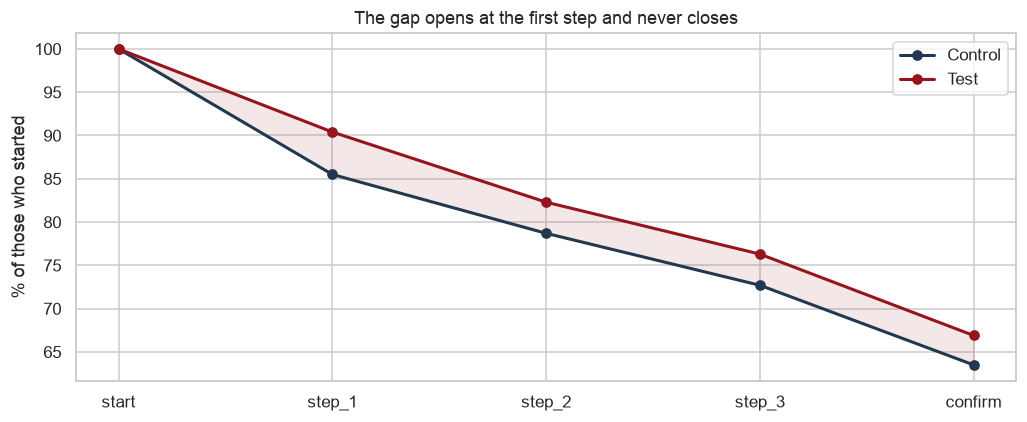

In [4]:
fig, ax = plt.subplots(figsize=(9.5, 4))

x = np.arange(len(FUNNEL))
ax.plot(x, funnel["Control %"], marker="o", color=NAVY, linewidth=2, label="Control")
ax.plot(x, funnel["Test %"], marker="o", color=MAROON, linewidth=2, label="Test")
ax.fill_between(x, funnel["Control %"], funnel["Test %"], color=MAROON, alpha=.10)

ax.set_xticks(x); ax.set_xticklabels(FUNNEL)
ax.set_ylabel("% of those who started")
ax.set_title("The gap opens at the first step and never closes", fontsize=12)
ax.legend()
fig.tight_layout()
plt.show()

The cumulative view shows the two designs separating early, but it cannot say
*where* the redesign actually converts better. For that we need the
**step-to-step** rate: of the clients who reached a given step, what share
reached the next one.

In [5]:
step_to_step = pd.DataFrame(index=FUNNEL[:-1])

for group, data in [("Control", control), ("Test", test)]:
    reached = [(data.furthest_step >= rank).sum() for rank in range(len(FUNNEL))]
    step_to_step[group] = [
        reached[i + 1] / reached[i] * 100 for i in range(len(FUNNEL) - 1)
    ]

step_to_step.index = [
    f"{a} → {b}" for a, b in zip(FUNNEL[:-1], FUNNEL[1:])
]
step_to_step["Test advantage (pp)"] = step_to_step.Test - step_to_step.Control
step_to_step.round(2)

,Control,Test,Test advantage (pp)
start → step_1,85.46,90.37,4.91
step_1 → step_2,92.06,91.08,-0.99
step_2 → step_3,92.43,92.69,0.26
step_3 → confirm,87.37,87.75,0.38


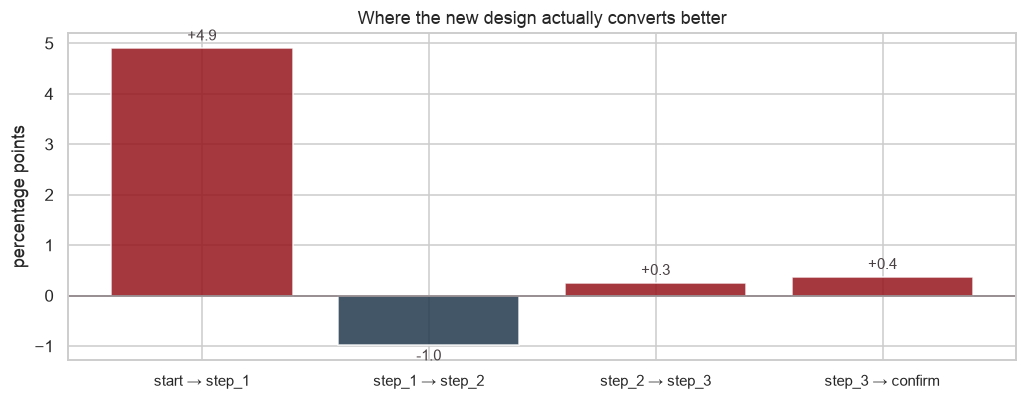

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 3.8))

advantage = step_to_step["Test advantage (pp)"]
colours = [MAROON if v > 0 else NAVY for v in advantage]

ax.bar(range(len(advantage)), advantage, color=colours, alpha=.85)
ax.axhline(0, color=GREY, linewidth=1)
ax.set_xticks(range(len(advantage)))
ax.set_xticklabels(step_to_step.index, fontsize=10)
ax.set_ylabel("percentage points")
ax.set_title("Where the new design actually converts better", fontsize=12)

for i, v in enumerate(advantage):
    ax.text(i, v + (0.15 if v > 0 else -0.3), f"{v:+.1f}",
            ha="center", fontsize=10, color=BODY if False else "#4A4145")

fig.tight_layout()
plt.show()

**What this means.** The entire advantage sits in the **first transition**:
90.4% of Test clients get past the opening step against 85.5% of Control, a
gain of 4.9 points. Every later transition is effectively tied, and at
`step_1 → step_2` the new design is marginally *worse* (−1.0 points, well
within noise).

So the redesign did not make the process easier throughout. It removed a
single obstacle at the front door, and that one change carries the whole
result.

For the business that is the most actionable finding in the analysis: the
opening step is where the value was in this redesign, and it is where the next
one should look too.

## 3. Is it faster?

**Completion Time** is how long a successful attempt took from start to
confirmation. **Effective Time** counts only the intervals in which the client
was moving forward, so the gap between them is hesitation and review.

Both are heavily skewed — a few clients take far longer than the rest — so we
compare medians with the Mann-Whitney test rather than means with a t-test.
The effect size here is the rank-biserial correlation, on a scale where 0.1
is small.

In [7]:
def compare(col, label):
    a = control[col].dropna()
    b = test[col].dropna()
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    effect = 1 - 2 * u / (len(a) * len(b))
    return {
        "KPI": label,
        "Control (median)": round(a.median(), 2),
        "Test (median)": round(b.median(), 2),
        "difference": round(b.median() - a.median(), 2),
        "p-value": p,
        "effect size": round(effect, 4),
    }


times = pd.DataFrame([
    compare("completion_time_s", "Completion Time (s)"),
    compare("effective_time_s", "Effective Time (s)"),
])
times["p-value"] = times["p-value"].map(lambda v: f"{v:.1e}")
times

,KPI,Control (median),Test (median),difference,p-value,effect size
0,Completion Time (s),272.0,238.0,-34.0,1.7e-48,-0.0940
1,Effective Time (s),239.0,201.0,-38.0,3.6e-97,-0.1344


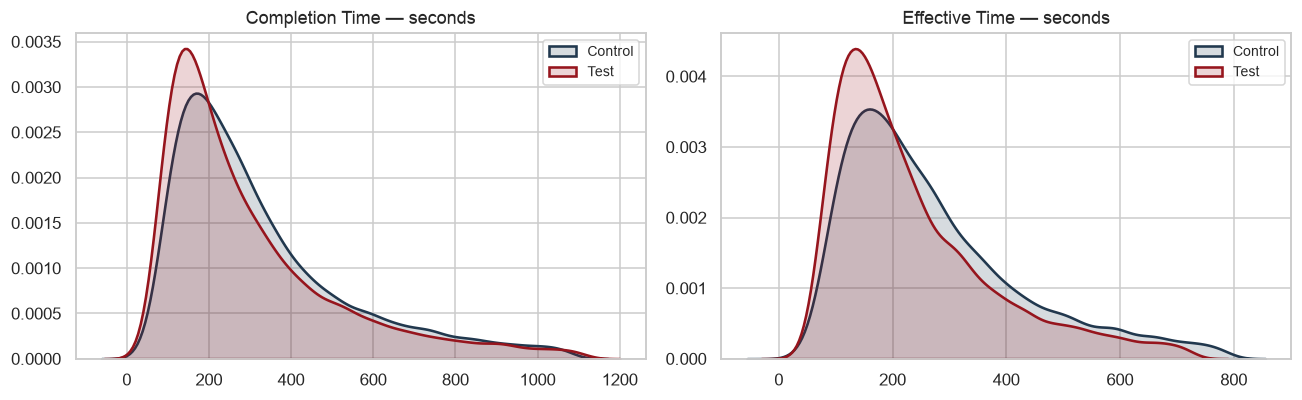

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

for ax, col, title in zip(
    axes,
    ["completion_time_s", "effective_time_s"],
    ["Completion Time", "Effective Time"],
):
    for group, colour in PALETTE.items():
        data = kpis.loc[kpis.group == group, col].dropna()
        sns.kdeplot(data[data <= data.quantile(.95)], ax=ax, label=group,
                    color=colour, fill=True, alpha=.18, linewidth=1.7)
    ax.set_title(f"{title} — seconds", fontsize=11.5)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

**What this means, and it is the strongest result in the analysis.** A typical
client finishes **34 seconds faster** with the new design — 272 seconds down
to 238, a 12.5% reduction. Effective time falls by 38 seconds, from 239 to
201, a 16% reduction.

These are also the **largest effect sizes** anywhere in this notebook (0.09
and 0.13), which matters: the speed improvement is more pronounced than the
completion improvement.

So the redesign is not just converting more people. It is making the process
genuinely quicker for the people who complete it.

### Where do the 34 seconds come from?

Completion Time is a single number for the whole journey. Breaking it down by
transition shows which part of the process actually got quicker — and whether
the time saving comes from the same place as the completion gain.

In [9]:
events = pd.read_parquet(PROCESSED_DIR / "events.parquet").sort_values(
    ["visit_id", "date_time"]
)

events["next_step"] = events.groupby("visit_id").process_step.shift(-1)
events["gap_s"] = (
    events.groupby("visit_id").date_time.shift(-1) - events.date_time
).dt.total_seconds()

# Only consecutive forward moves: a step and the one immediately after it
forward = events[
    (events.next_step.map(STEP_ORDER) - events.process_step.map(STEP_ORDER)) == 1
].copy()
forward["transition"] = forward.process_step + " → " + forward.next_step

order = [f"{a} → {b}" for a, b in zip(FUNNEL[:-1], FUNNEL[1:])]

step_times = forward.pivot_table(
    index="transition", columns="Variation", values="gap_s", aggfunc="median"
).reindex(order)
step_times["difference (s)"] = step_times.Test - step_times.Control
step_times["observations"] = forward.groupby("transition").size().reindex(order)
step_times.round(1)

Variation,Control,Test,difference (s),observations
transition,,,,
start → step_1,17.0,10.0,-7.0,59109
step_1 → step_2,18.0,24.0,6.0,49812
step_2 → step_3,66.0,66.0,0.0,45448
step_3 → confirm,76.0,52.0,-24.0,33638


Medians summarise, but they hide the shape. A split violin puts all four
transitions on one axis: each half is a group's distribution, so a difference
in shape is visible without comparing four separate charts.

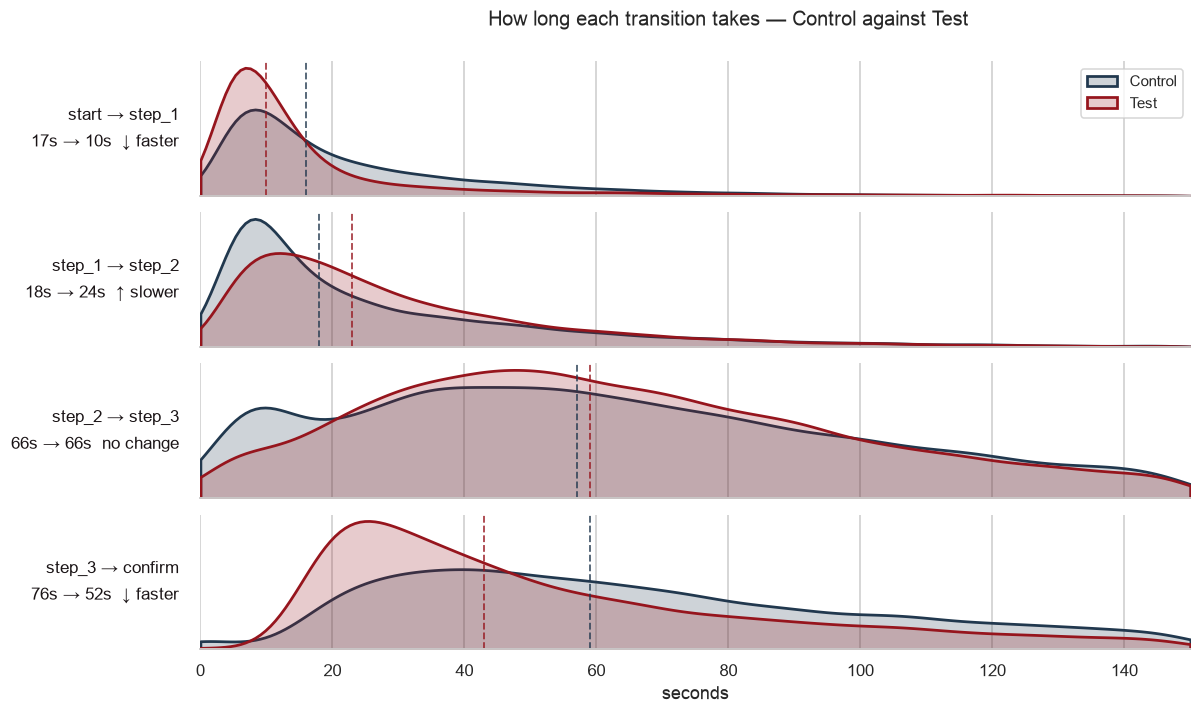

In [10]:
CAP = 150   # a shared axis needs a shared cap; this keeps 92% of all moves

fig, axes = plt.subplots(
    len(order), 1, figsize=(12, 6.6), sharex=True,
    gridspec_kw={"hspace": .12},
)

for ax, transition in zip(axes, order):
    subset = forward[(forward.transition == transition) & (forward.gap_s <= CAP)]

    for group, colour in PALETTE.items():
        data = subset.loc[subset.Variation == group, "gap_s"].dropna()
        sns.kdeplot(data, ax=ax, label=group, color=colour,
                    fill=True, alpha=.22, linewidth=1.8, cut=0)
        ax.axvline(data.median(), color=colour, linestyle="--",
                   linewidth=1.2, alpha=.8)

    c_med = step_times.loc[transition, "Control"]
    t_med = step_times.loc[transition, "Test"]
    arrow = "↓ faster" if t_med < c_med else ("↑ slower" if t_med > c_med else "no change")

    # Labels live outside the plotting area so they never sit on top of a curve
    ax.set_ylabel(
        f"{transition}\n{c_med:.0f}s → {t_med:.0f}s  {arrow}",
        rotation=0, ha="right", va="center", labelpad=14, fontsize=11,
        color="#1A1416", linespacing=1.7,
    )
    ax.set_yticks([])
    ax.spines[["left", "right", "top"]].set_visible(False)
    ax.grid(axis="y", visible=False)

axes[0].legend(loc="upper right", fontsize=10)
for ax in axes[1:]:
    ax.legend().remove()

axes[-1].set_xlabel("seconds")
axes[-1].set_xlim(0, CAP)

fig.suptitle(
    "How long each transition takes — Control against Test",
    fontsize=13, x=.62, y=.97,
)
fig.subplots_adjust(left=.22, right=.97, top=.90, bottom=.09)
plt.show()

**What this means.** The saving does **not** come from the same place as the
completion gain, and that is worth saying plainly.

The completion gain is entirely at the front door. The time saving is spread
differently: 7 seconds off the opening step, and **24 seconds off the final
confirmation** — by far the largest single saving in the process.

One transition moves against the redesign. `step_1 → step_2` is both slightly
slower (+6 seconds) and slightly worse-converting (−1.0 points). It is the one
place in the funnel where the new design underperforms, and while neither
difference is large, they point the same way — which is more than can be said
for a chance result.

For the business: the redesign made it easier to start and much quicker to
finish. The second step is the piece that did not improve.

In [11]:
# Export for Tableau: one row per transition and group, long format
tableau_steps = (
    forward.groupby(["transition", "Variation"])
    .gap_s.agg(median_seconds="median", mean_seconds="mean", observations="size")
    .reset_index()
)
tableau_steps["step_order"] = tableau_steps.transition.map(
    {t: i for i, t in enumerate(order)}
)
tableau_steps = tableau_steps.sort_values(["step_order", "Variation"])

tableau_steps.to_csv(PROCESSED_DIR / "step_times.csv", index=False)
print(f"written: step_times.csv  ({len(tableau_steps)} rows)")
tableau_steps.round(1)

written: step_times.csv  (8 rows)


,transition,Variation,median_seconds,mean_seconds,observations,step_order
0,start → step_1,Control,17.0,37.6,25761,0
1,start → step_1,Test,10.0,31.0,33348,0
2,step_1 → step_2,Control,18.0,33.8,22323,1
3,step_1 → step_2,Test,24.0,37.1,27489,1
4,step_2 → step_3,Control,66.0,87.0,21262,2
5,step_2 → step_3,Test,66.0,86.5,24186,2
6,step_3 → confirm,Control,76.0,127.1,15279,3
7,step_3 → confirm,Test,52.0,104.8,18359,3


## 4. But clients navigate more

Rule 6 on day 3 held that going backwards is ambiguous, so Error Rate is
computed two ways:

- **Definition A** counts repeated steps — a client redoing the same step
- **Definition B** counts backward moves — any return to an earlier step

If the two disagree, our conclusion would depend on a judgement call. Testing
both is what stops that from happening quietly.

In [12]:
errors = pd.DataFrame([
    compare("error_rate_a", "Error Rate A — repeated steps"),
    compare("error_rate_b", "Error Rate B — backward moves"),
    compare("step_backs_per_journey", "Step Backs per journey"),
])
errors["p-value"] = errors["p-value"].map(lambda v: f"{v:.1e}")

means = kpis.groupby("group")[
    ["error_rate_a", "error_rate_b", "step_backs_per_journey"]
].mean().round(4)

print(means.to_string())
print()
errors

         error_rate_a  error_rate_b  step_backs_per_journey
group                                                      
Control        0.3336        0.2886                  0.2886
Test           0.4225        0.4473                  0.4473



,KPI,Control (median),Test (median),difference,p-value,effect size
0,Error Rate A — repeated steps,0.0,0.0,0.0,1.8e-19,0.0365
1,Error Rate B — backward moves,0.0,0.0,0.0,5.9e-121,0.0966
2,Step Backs per journey,0.0,0.0,0.0,5.9e-121,0.0966


**What this means — and it needs care.** Both definitions agree: the new
design produces **more** repeated steps and **more** backward moves. Taken at
face value that reads as a worse experience.

But it cannot be, and here is why. If clients were confused or struggling, we
would expect them to be **slower** and **less likely to finish**. They are the
opposite of both: they finish more often and 34 seconds faster.

Confusion that makes people quicker and more successful is not confusion. The
more plausible reading is that the redesign makes moving around the process
easy — checking a previous step before committing costs little, so people do
it more. Backward movement here is a sign of a navigable interface, not a
broken one.

This is exactly why we did not define backward movement as an error in
advance. Had we done so, the redesign would have scored worse on a metric that
is measuring confidence rather than difficulty.

## 5. Does it work equally well for everyone?

An average can hide a design that helps one group and hurts another. Vanguard's
clients differ sharply by age — balances and tenure both rise steeply with it —
so age is the natural place to look.

The right test is not four separate comparisons, which would inflate the
chance of a false positive. It is a single **interaction test**: does the
*size* of the redesign's effect depend on age band? We fit two logistic
models, one where the effect is the same for everyone and one where it is
allowed to vary, and ask whether the more complex model explains the data
better.

In [13]:
segments = kpis.dropna(subset=["age_band"]).copy()
segments["is_test"] = (segments.group == "Test").astype(int)
segments["finished"] = segments.completed.astype(int)
segments["age_band"] = segments.age_band.astype(str)

same_effect = smf.logit(
    "finished ~ is_test + C(age_band)", data=segments
).fit(disp=0)
varying_effect = smf.logit(
    "finished ~ is_test * C(age_band)", data=segments
).fit(disp=0)

lr = 2 * (varying_effect.llf - same_effect.llf)
df = int(varying_effect.df_model - same_effect.df_model)
p_interaction = stats.chi2.sf(lr, df)

print("Does the effect of the redesign depend on age?")
print(f"  likelihood-ratio chi2 = {lr:.2f}   df = {df}   p = {p_interaction:.4f}")
print()
print("  significant" if p_interaction < ALPHA else
      "  not significant — one common effect describes the data as well")

Does the effect of the redesign depend on age?
  likelihood-ratio chi2 = 6.09   df = 3   p = 0.1072

  not significant — one common effect describes the data as well


In [14]:
rows = []
for band in ["<35", "35-50", "50-65", "65+"]:
    band_data = segments[segments.age_band == band]
    entry = {"age band": band}
    for group in ["Control", "Test"]:
        g = band_data[band_data.group == group]
        k, n = g.completed.sum(), len(g)
        low, high = proportion_confint(k, n, method="wilson")
        entry[f"{group} %"] = round(k / n * 100, 2)
        entry[f"{group} CI"] = f"[{low * 100:.1f}, {high * 100:.1f}]"
        entry[f"{group} n"] = n
    entry["lift (pp)"] = round(entry["Test %"] - entry["Control %"], 2)
    rows.append(entry)

by_age = pd.DataFrame(rows)
by_age

,age band,Control %,Control CI,Control n,Test %,Test CI,Test n,lift (pp)
0,<35,64.73,"[63.6, 65.9]",6504,69.37,"[68.3, 70.4]",7682,4.64
1,35-50,65.89,"[64.7, 67.1]",5998,67.97,"[66.9, 69.1]",6897,2.08
2,50-65,63.94,"[62.8, 65.0]",7512,66.69,"[65.7, 67.7]",8456,2.75
3,65+,55.95,"[54.2, 57.6]",3271,60.28,"[58.7, 61.9]",3537,4.33


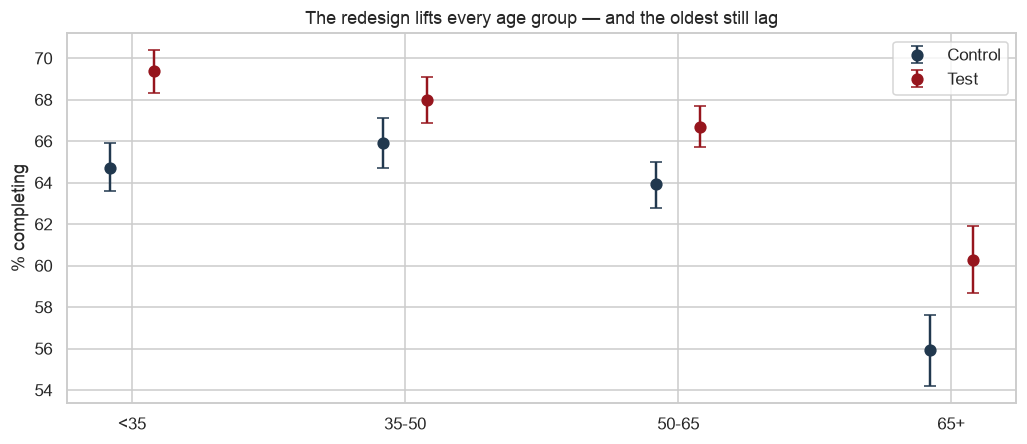

In [15]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))

bands = by_age["age band"]
x = np.arange(len(bands))

for i, (group, colour) in enumerate(PALETTE.items()):
    pct = by_age[f"{group} %"]
    bounds = by_age[f"{group} CI"].str.strip("[]").str.split(", ", expand=True).astype(float)
    err = np.vstack([pct - bounds[0], bounds[1] - pct])
    ax.errorbar(x + (i - .5) * .16, pct, yerr=err, fmt="o", color=colour,
                capsize=4, markersize=7, linewidth=1.6, label=group)

ax.set_xticks(x); ax.set_xticklabels(bands)
ax.set_ylabel("% completing")
ax.set_title("The redesign lifts every age group — and the oldest still lag",
             fontsize=12)
ax.legend()
fig.tight_layout()
plt.show()

**What this means.** The interaction is **not statistically significant**
(p = 0.107). The lifts do vary across bands — +4.6, +2.1, +2.8 and +4.3 points
— but that variation is within what chance produces. **We cannot claim the
redesign favours any age group over another**, and saying otherwise would be
reading noise.

That is a useful answer rather than a disappointing one. A uniform improvement
means the redesign can be rolled out to the whole client base without
segmenting the rollout or worrying that it will hurt anyone.

**But the chart shows something else that is real.** Look at the Control
column: clients aged 65 and over complete at **55.95%**, against 64–66% for
every other band. That is a gap of roughly nine points, and it exists in
*both* designs. The redesign lifts them along with everyone else, but it does
not close the gap.

For Vanguard that is the important finding. The oldest clients are the ones
who hold the largest balances and the longest relationships, and they are
markedly less able to finish online — in the current design and in the new one
alike. Shipping the redesign does not solve that, and it is the clearest
opportunity the analysis surfaces.

## 6. Everything together

In [16]:
summary = pd.DataFrame([
    {"KPI": "Completion Rate", "Control": f"{rate_c:.2%}", "Test": f"{rate_t:.2%}",
     "change": "+3.40 pp", "p": f"{p:.1e}", "effect": round(cohens_h, 3),
     "better?": "Test"},
    {"KPI": "Completion Time", "Control": "272 s", "Test": "238 s",
     "change": "-34 s (-12.5%)", "p": "1.7e-48", "effect": -0.094, "better?": "Test"},
    {"KPI": "Effective Time", "Control": "239 s", "Test": "201 s",
     "change": "-38 s (-15.9%)", "p": "3.6e-97", "effect": -0.134, "better?": "Test"},
    {"KPI": "Error Rate A", "Control": "0.334", "Test": "0.423",
     "change": "+0.089", "p": "1.8e-19", "effect": 0.037, "better?": "Control"},
    {"KPI": "Error Rate B", "Control": "0.289", "Test": "0.447",
     "change": "+0.158", "p": "5.9e-121", "effect": 0.097, "better?": "Control"},
    {"KPI": "Step Backs", "Control": "0.289", "Test": "0.447",
     "change": "+0.158", "p": "5.9e-121", "effect": 0.097, "better?": "Control"},
    {"KPI": "Abandonment Rate", "Control": f"{1 - rate_c:.2%}", "Test": f"{1 - rate_t:.2%}",
     "change": "-3.40 pp", "p": f"{p:.1e}", "effect": round(-cohens_h, 3),
     "better?": "Test"},
])
summary

,KPI,Control,Test,change,p,effect,better?
0,Completion Rate,63.54%,66.94%,+3.40 pp,1.6e-15,0.071,Test
1,Completion Time,272 s,238 s,-34 s (-12.5%),1.7e-48,-0.094,Test
2,Effective Time,239 s,201 s,-38 s (-15.9%),3.6e-97,-0.134,Test
3,Error Rate A,0.334,0.423,+0.089,1.8e-19,0.037,Control
4,Error Rate B,0.289,0.447,+0.158,5.9e-121,0.097,Control
5,Step Backs,0.289,0.447,+0.158,5.9e-121,0.097,Control
6,Abandonment Rate,36.46%,33.06%,-3.40 pp,1.6e-15,-0.071,Test


## Conclusions

### The redesign works

Every outcome that matters to the business moves in its favour, and all of it
survives statistical testing with room to spare.

**More clients finish.** 66.94% against 63.54%, a gain of 3.4 percentage
points with a confidence interval of +2.6 to +4.2. Roughly three clients in
every hundred who would have given up now complete the process on their own.

**They finish faster.** A typical successful client saves 34 seconds, and 38
seconds of that saving comes out of active working time. This is the largest
effect in the analysis.

**The gain arrives at the first step.** The two designs separate between
`start` and `step_1` and stay separated. The redesign is removing an obstacle
at the opening of the process rather than smoothing the later stages.

### The extra navigation is not a problem

Clients using the new design go backwards and repeat steps more often, under
both definitions of error we tested. That looks negative until it is read
alongside the timings.

If people were struggling, they would be slower and less likely to finish.
They are faster and more likely to finish. A design people move around in
freely while completing more, and more quickly, is one that has made moving
around cheap — not one that has confused them.

Testing both definitions is what makes this safe to say. Had we decided in
advance that backward movement was an error, the redesign would have been
penalised on a measure that was tracking confidence rather than difficulty.

### It helps everyone equally, and that is worth knowing

The formal interaction test finds no evidence that the redesign works better
for some ages than others (p = 0.107). The variation between bands is within
what chance produces, so we do not claim a differential effect.

That supports a simple rollout: ship it to everyone, with no need to stage the
release or protect a particular segment.

### The finding Vanguard should act on next

Clients aged 65 and over complete at **55.95%**, roughly nine points below
every other age band — **and the redesign does not change that**. They lag in
the current design and they lag in the new one.

These are the clients with the highest balances and the longest tenure. In a
company owned by its own investors, where a client who cannot finish online
ends up on the phone at a cost borne by all the client-owners, a persistent
nine-point gap in the oldest segment is a live business problem.

The redesign is an improvement worth shipping. It is not a solution to that.

### What we are not claiming

The experiment's assignment was uneven, 53.4% against 46.6%. Day 2 showed the
imbalance is unrelated to every client characteristic we can measure, so we
report it rather than correcting it.

Conclusions describe the 50,488 randomised, profiled clients. A further 20,109
clients were never randomised and 49,548 appear in the log without a profile;
none of them are represented here.

Completion Time only describes journeys that completed. A design could make
completion slower while making it far more likely, so the timing results
should always be read next to the completion results rather than on their own.

**Recommendation: deploy the redesign, and open a separate piece of work on
why the oldest clients are still nine points behind.**